# 06 Inference Optimization：推理优化——KV Cache 与量化

> 前置：`deep-learning-architectures/04-transformer-architecture`（自注意力）、`linear-algebra`。
> 目标：用计时实验证明 **KV Cache** 为什么是自回归推理的标配；理解**权重量化**如何把 7B 模型塞进消费级显卡。

## 自回归解码的浪费

生成第 $T$ 个 token 时，朴素实现会**重新计算前 $T-1$ 个 token 的 K、V**——但它们每一步都一样！KV Cache 把已算好的 K、V 缓存下来，每步只算新 token 的 Q/K/V 并追加。

复杂度（d 视为常数）：朴素每步对**增长的前缀**重算 attention，累计 $O(T^3)$；带 cache 每步只算一个新 token，累计 $O(T^2)$——对长序列这是数量级的差距。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, time
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


In [2]:
class DecoderOnly(nn.Module):
    """单层单头解码器：用于 KV cache 计时实验。"""
    def __init__(self, d=96, vocab=256):
        super().__init__()
        self.d = d
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Parameter(torch.randn(512, d) * 0.02)
        self.Wq = nn.Linear(d, d); self.Wk = nn.Linear(d, d)
        self.Wv = nn.Linear(d, d); self.Wo = nn.Linear(d, d)
        self.head = nn.Linear(d, vocab)
        self.register_buffer("mask", torch.triu(torch.ones(512, 512), diagonal=1).bool())
    def forward(self, idx):
        """朴素：整段重算。"""
        B, T = idx.shape
        x = self.tok(idx) + self.pos[:T]
        q, k, v = self.Wq(x), self.Wk(x), self.Wv(x)
        s = q @ k.transpose(-2, -1) / math.sqrt(self.d)
        s = s.masked_fill(self.mask[:T, :T], float("-inf"))
        a = torch.softmax(s, dim=-1)
        return self.head(self.Wo(a @ v))
    def step(self, xt, K, V):
        """带 cache：只算新 token，K/V 追加。"""
        t = K.shape[1]
        x = self.tok(xt) + self.pos[t:t + 1]
        q, k, v = self.Wq(x), self.Wk(x), self.Wv(x)
        K = torch.cat([K, k], 1); V = torch.cat([V, v], 1)
        s = q @ K.transpose(-2, -1) / math.sqrt(self.d)      # (1, t+1)
        s = s.masked_fill(self.mask[t, :t + 1], float("-inf"))
        a = torch.softmax(s, dim=-1)
        return self.head(self.Wo(a @ V)), K, V

model = DecoderOnly()
torch.manual_seed(0)
with torch.no_grad():
    model(torch.randint(0, 256, (1, 20)))   # 预热，避免首次调用的内核加载计入计时
print("参数量:", sum(p.numel() for p in model.parameters()))

参数量: 135808


## 计时对比：随生成长度缩放

对每个长度 T，比较两条路径：

- **朴素**：模拟真实无 cache 生成——第 $t$ 步对前缀 $x_{1:t}$ 整段前向；
- **KV Cache**：逐 token 只算新 token，K/V 追加到缓存。

重复多次取平均。小模型上 Python 循环有固定开销，所以**越大的 T，cache 的复杂度优势越明显**。

T=  20  朴素=   1.24 ms  cache=   0.72 ms  加速=  1.7x
T=  50  朴素=   2.92 ms  cache=   1.76 ms  加速=  1.7x
T= 100  朴素=   6.59 ms  cache=   3.51 ms  加速=  1.9x
T= 200  朴素=  18.14 ms  cache=   7.08 ms  加速=  2.6x


T= 400  朴素=  67.81 ms  cache=  15.98 ms  加速=  4.2x


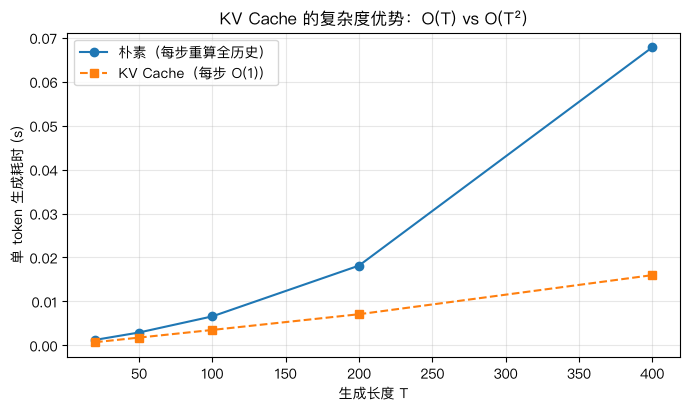

In [3]:
def time_naive(T, n=3):
    # 朴素生成：每步把已生成的前缀整段重算一次（真实无 cache 场景）
    idx = torch.randint(0, 256, (1, T))
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n):
            for t in range(1, T + 1):
                model(idx[:, :t])
    return (time.perf_counter() - t0) / n

def time_cached(T, n=3):
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n):
            K = V = torch.zeros(1, 0, model.d)
            xt = torch.tensor([[3]])
            for _ in range(T):
                _, K, V = model.step(xt, K, V)
    return (time.perf_counter() - t0) / n

lengths = [20, 50, 100, 200, 400]
naive_t, cached_t = [], []
for T in lengths:
    nt = time_naive(T); ct = time_cached(T)
    naive_t.append(nt); cached_t.append(ct)
    print(f"T={T:4d}  朴素={nt*1000:7.2f} ms  cache={ct*1000:7.2f} ms  加速={nt/ct:5.1f}x")

plt.figure(figsize=(7, 4.2))
plt.plot(lengths, naive_t, "o-", label="朴素（每步重算全历史）")
plt.plot(lengths, cached_t, "s--", label="KV Cache（每步 O(1)）")
plt.xlabel("生成长度 T"); plt.ylabel("单 token 生成耗时 (s)")
plt.title("KV Cache 的复杂度优势：O(T) vs O(T²)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 量化：把 7B 装进显存

KV Cache 解决了"重复计算"，但模型本身还是太大。**量化**把权重从 16/32 位降到 8/4 位。对称量化：

$$W_q = \operatorname{round}\left(\frac{W}{s}\right), \qquad s = \frac{\max|W|}{2^{b-1}-1} \qquad \text{（反量化 } \hat W = W_q \cdot s\text{）}$$

对推理来说，权重是**只读**的——量化后每层按需反量化即可，显存直接除以 4/8。

In [4]:
def quantize(W, bits):
    s = W.abs().max() / (2 ** (bits - 1) - 1)
    Wq = torch.clamp(torch.round(W / s), -(2 ** (bits - 1)), 2 ** (bits - 1) - 1)
    return Wq * s

lin = nn.Linear(128, 128)
x = torch.randn(2000, 128)
with torch.no_grad():
    y = lin(x)
    for bits in (8, 4):
        yq = x @ quantize(lin.weight, bits).T + lin.bias
        rel = (y - yq).abs().mean().item() / y.abs().mean().item()
        mem = 128 * 128 * bits / 8
        print(f"{bits}-bit: 相对误差 = {rel:.4f}  权重显存 = {mem/1024:.0f} KB（fp32 为 64 KB）")

# 真实数字：Llama-2 7B 的 KV cache 显存
print("\nLlama-2 7B KV cache 估算（32 层，d=4096，KV 头 32，seq=4096）:")
print("每层每 token 的 KV 字节 = 2 × d_kv × kv_heads × 2 bytes = 2×128×32×2 = 16 KB")
print("全序列 = 16 KB × 4096 token × 32 层 = 2 GB (fp16)")
print("→ 这就是为什么长上下文必须上 KV 量化/分组查询注意力(GQA)")

8-bit: 相对误差 = 0.0039  权重显存 = 16 KB（fp32 为 64 KB）
4-bit: 相对误差 = 0.0707  权重显存 = 8 KB（fp32 为 64 KB）

Llama-2 7B KV cache 估算（32 层，d=4096，KV 头 32，seq=4096）:
每层每 token 的 KV 字节 = 2 × d_kv × kv_heads × 2 bytes = 2×128×32×2 = 16 KB
全序列 = 16 KB × 4096 token × 32 层 = 2 GB (fp16)
→ 这就是为什么长上下文必须上 KV 量化/分组查询注意力(GQA)


## 推理优化的完整工具箱

| 方法 | 原理 | 收益 |
|---|---|---|
| KV Cache | 缓存历史 K/V | 复杂度 O(T²)→O(T) |
| GQA / MQA | 多查询共享 KV 头 | KV 显存 /8~/32 |
| 量化（GPTQ/AWQ） | 4-bit 权重 | 显存 /4，速度↑ |
| 投机解码 | 小模型草稿+大模型验证 | 2~3× 加速 |
| 连续批处理 | 动态拼接请求 | 吞吐 ×10 |
| 蒸馏 | 大模型教小模型 | 部署体积↓ |

**本课要点**：KV Cache 解决"重复计算"，量化解决"装不下"——两者是 LLM 服务端部署的最低门槛。

## 课后练习

1. 把 `d` 从 32 提到 128 再计时，观察两曲线差距是否拉大（O(T²) vs O(T) 的常数差异）。
2. 用"每层只缓存 K 不缓存 V"（MQA 风格）重做计时与显存估算，说明 GQA 为何在长序列上必备。
3. 对 `quantize` 加 per-channel 量化（每行独立 scale），对比误差——理解 GPTQ/AWQ 的改进方向。